
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### get the dataset from drive

In [2]:
dataset_path = "/content/drive/MyDrive/Dataset/PL-Matches-Data"
# inside the dataset there are multiple csv (ex: season-1617.csv, season-1718.csv, season 1819.csv, etc)


In [3]:
import os

all_files = os.listdir(dataset_path)
csv_files = [f for f in all_files if f.endswith('.csv')]

# Sort the files to ensure consistent order, if necessary (e.g., season-1617, season-1718)
csv_files.sort()

df_list = []

for csv_file in csv_files:
    file_path = os.path.join(dataset_path, csv_file)
    try:
        df = pd.read_csv(file_path)
        df_list.append(df)
        print(f"Loaded {csv_file} with {len(df)} rows.")
    except Exception as e:
        print(f"Error loading {csv_file}: {e}")

if df_list:
    final_df = pd.concat(df_list, ignore_index=True)
    print(f"\nSuccessfully merged {len(df_list)} CSV files into a single DataFrame.")
    print(f"Final DataFrame has {len(final_df)} rows and {len(final_df.columns)} columns.")
    display(final_df.head())
else:
    print("No CSV files were loaded.")

Loaded season-1617.csv with 380 rows.
Loaded season-1718.csv with 380 rows.
Loaded season-1819.csv with 380 rows.
Loaded season-1920.csv with 380 rows.
Loaded season-2021.csv with 380 rows.
Loaded season-2122.csv with 380 rows.
Loaded season-2223.csv with 380 rows.
Loaded season-2324.csv with 380 rows.
Loaded season-2425.csv with 380 rows.
Loaded season-2526.csv with 380 rows.

Successfully merged 10 CSV files into a single DataFrame.
Final DataFrame has 3800 rows and 22 columns.


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,2016-08-13,Burnley,Swansea,0,1,A,0,0,D,J Moss,...,3,9,10,14,7,4,3,2,0,0
1,2016-08-13,Crystal Palace,West Brom,0,1,A,0,0,D,C Pawson,...,4,3,12,15,3,6,2,2,0,0
2,2016-08-13,Everton,Tottenham,1,1,D,1,0,H,M Atkinson,...,6,4,10,14,5,6,0,0,0,0
3,2016-08-13,Hull,Leicester,2,1,H,1,0,H,M Dean,...,5,5,8,17,5,3,2,2,0,0
4,2016-08-13,Man City,Sunderland,2,1,H,1,0,H,R Madley,...,4,3,11,14,9,6,1,2,0,0


In [4]:
# check some rows from the last
final_df.tail(5)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
3795,2026-05-24,Man City,Aston Villa,1,2,A,1,0,H,A Madley,...,3,5,8,4,9,4,1,0,0,0
3796,2026-05-24,Nott'm Forest,Bournemouth,1,1,D,1,0,H,C Pawson,...,5,4,11,7,6,3,1,1,0,0
3797,2026-05-24,Sunderland,Chelsea,2,1,H,1,0,H,C Kavanagh,...,2,1,15,18,7,7,3,2,0,0
3798,2026-05-24,Tottenham,Everton,1,0,H,1,0,H,M Oliver,...,6,3,15,12,6,2,5,3,0,1
3799,2026-05-24,West Ham,Leeds,3,0,H,0,0,D,A Taylor,...,9,3,11,14,6,4,0,3,0,0


In [5]:
# Make the column names understandable
column_mapping = {
    'Date': 'Match_Date',
    'HomeTeam': 'Home_Team',
    'AwayTeam': 'Away_Team',
    'FTHG': 'Full_Time_Home_Goals',
    'FTAG': 'Full_Time_Away_Goals',
    'FTR': 'Full_Time_Result',
    'HTHG': 'Half_Time_Home_Goals',
    'HTAG': 'Half_Time_Away_Goals',
    'HTR': 'Half_Time_Result',
    'Referee': 'Match_Referee',
    'HS': 'Home_Team_Shots',
    'AS': 'Away_Team_Shots',
    'HST': 'Home_Team_Shots_On_Target',
    'AST': 'Away_Team_Shots_On_Target',
    'HF': 'Home_Team_Fouls_Committed',
    'AF': 'Away_Team_Fouls_Committed',
    'HC': 'Home_Team_Corners',
    'AC': 'Away_Team_Corners',
    'HY': 'Home_Team_Yellow_Cards',
    'AY': 'Away_Team_Yellow_Cards',
    'HR': 'Home_Team_Red_Cards',
    'AR': 'Away_Team_Red_Cards'
}

final_df = final_df.rename(columns=column_mapping)
# make all column names lower case
final_df.columns = final_df.columns.str.lower()
display(final_df.head())

,match_date,home_team,away_team,full_time_home_goals,full_time_away_goals,full_time_result,half_time_home_goals,half_time_away_goals,half_time_result,match_referee,...,home_team_shots_on_target,away_team_shots_on_target,home_team_fouls_committed,away_team_fouls_committed,home_team_corners,away_team_corners,home_team_yellow_cards,away_team_yellow_cards,home_team_red_cards,away_team_red_cards
0,2016-08-13,Burnley,Swansea,0,1,A,0,0,D,J Moss,...,3,9,10,14,7,4,3,2,0,0
1,2016-08-13,Crystal Palace,West Brom,0,1,A,0,0,D,C Pawson,...,4,3,12,15,3,6,2,2,0,0
2,2016-08-13,Everton,Tottenham,1,1,D,1,0,H,M Atkinson,...,6,4,10,14,5,6,0,0,0,0
3,2016-08-13,Hull,Leicester,2,1,H,1,0,H,M Dean,...,5,5,8,17,5,3,2,2,0,0
4,2016-08-13,Man City,Sunderland,2,1,H,1,0,H,R Madley,...,4,3,11,14,9,6,1,2,0,0


In [6]:
# save the final dataset into local
final_df.to_csv('pl-matches-dataset.csv', index=False)
final_dataset = pd.read_csv('pl-matches-dataset.csv')
final_dataset.head()


,match_date,home_team,away_team,full_time_home_goals,full_time_away_goals,full_time_result,half_time_home_goals,half_time_away_goals,half_time_result,match_referee,...,home_team_shots_on_target,away_team_shots_on_target,home_team_fouls_committed,away_team_fouls_committed,home_team_corners,away_team_corners,home_team_yellow_cards,away_team_yellow_cards,home_team_red_cards,away_team_red_cards
0,2016-08-13,Burnley,Swansea,0,1,A,0,0,D,J Moss,...,3,9,10,14,7,4,3,2,0,0
1,2016-08-13,Crystal Palace,West Brom,0,1,A,0,0,D,C Pawson,...,4,3,12,15,3,6,2,2,0,0
2,2016-08-13,Everton,Tottenham,1,1,D,1,0,H,M Atkinson,...,6,4,10,14,5,6,0,0,0,0
3,2016-08-13,Hull,Leicester,2,1,H,1,0,H,M Dean,...,5,5,8,17,5,3,2,2,0,0
4,2016-08-13,Man City,Sunderland,2,1,H,1,0,H,R Madley,...,4,3,11,14,9,6,1,2,0,0


#### Data Cleaning: Handling Missing Values

In [7]:
# Check for null values in the DataFrame
null_counts = final_df.isnull().sum()

# Display columns with null values and their counts
print("Number of null values per column:")
display(null_counts[null_counts > 0].sort_values(ascending=False))

Number of null values per column:


,0


In [14]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   match_date                 3800 non-null   object
 1   home_team                  3800 non-null   object
 2   away_team                  3800 non-null   object
 3   full_time_home_goals       3800 non-null   int64 
 4   full_time_away_goals       3800 non-null   int64 
 5   full_time_result           3800 non-null   object
 6   half_time_home_goals       3800 non-null   int64 
 7   half_time_away_goals       3800 non-null   int64 
 8   half_time_result           3800 non-null   object
 9   match_referee              3800 non-null   object
 10  home_team_shots            3800 non-null   int64 
 11  away_team_shots            3800 non-null   int64 
 12  home_team_shots_on_target  3800 non-null   int64 
 13  away_team_shots_on_target  3800 non-null   int64 
 14  home_tea

In [15]:
# check unique values of each features
for column in final_df.columns:
    unique_values = final_df[column].unique()
    print(f"Unique values in column '{column}':")
    print(unique_values)
    print()

Unique values in column 'match_date':
['2016-08-13' '2016-08-14' '2016-08-15' ... '2026-05-18' '2026-05-19'
 '2026-05-24']

Unique values in column 'home_team':
['Burnley' 'Crystal Palace' 'Everton' 'Hull' 'Man City' 'Middlesbrough'
 'Southampton' 'Arsenal' 'Bournemouth' 'Chelsea' 'Man United' 'Leicester'
 'Stoke' 'Swansea' 'Tottenham' 'Watford' 'West Brom' 'Sunderland'
 'West Ham' 'Liverpool' 'Brighton' 'Newcastle' 'Huddersfield' 'Fulham'
 'Wolves' 'Cardiff' 'Aston Villa' 'Norwich' 'Sheffield United' 'Leeds'
 'Brentford' "Nott'm Forest" 'Luton' 'Ipswich']

Unique values in column 'away_team':
['Swansea' 'West Brom' 'Tottenham' 'Leicester' 'Sunderland' 'Stoke'
 'Watford' 'Liverpool' 'Man United' 'West Ham' 'Southampton' 'Arsenal'
 'Man City' 'Hull' 'Crystal Palace' 'Chelsea' 'Everton' 'Middlesbrough'
 'Bournemouth' 'Burnley' 'Huddersfield' 'Brighton' 'Newcastle' 'Cardiff'
 'Wolves' 'Fulham' 'Norwich' 'Sheffield United' 'Aston Villa' 'Leeds'
 'Brentford' "Nott'm Forest" 'Luton' 'Ipswich

## Exploratory Data Analysis (EDA)

### 1. Distribution of Full Time Results (FTR)

Distribution of Full Time Results:


,proportion
full_time_result,
H,44.631579
A,32.131579
D,23.236842


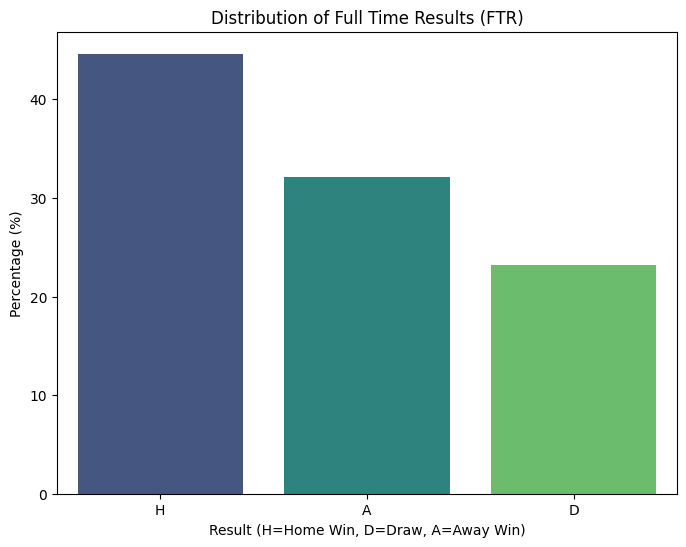

In [8]:
# Calculate the distribution of Full Time Results
ftr_distribution = final_df['full_time_result'].value_counts(normalize=True) * 100

print("Distribution of Full Time Results:")
display(ftr_distribution)

# Visualize the distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=ftr_distribution.index, y=ftr_distribution.values, palette='viridis')
plt.title('Distribution of Full Time Results (FTR)')
plt.xlabel('Result (H=Home Win, D=Draw, A=Away Win)')
plt.ylabel('Percentage (%)')
plt.show()

### 2. Distribution of Goals Scored

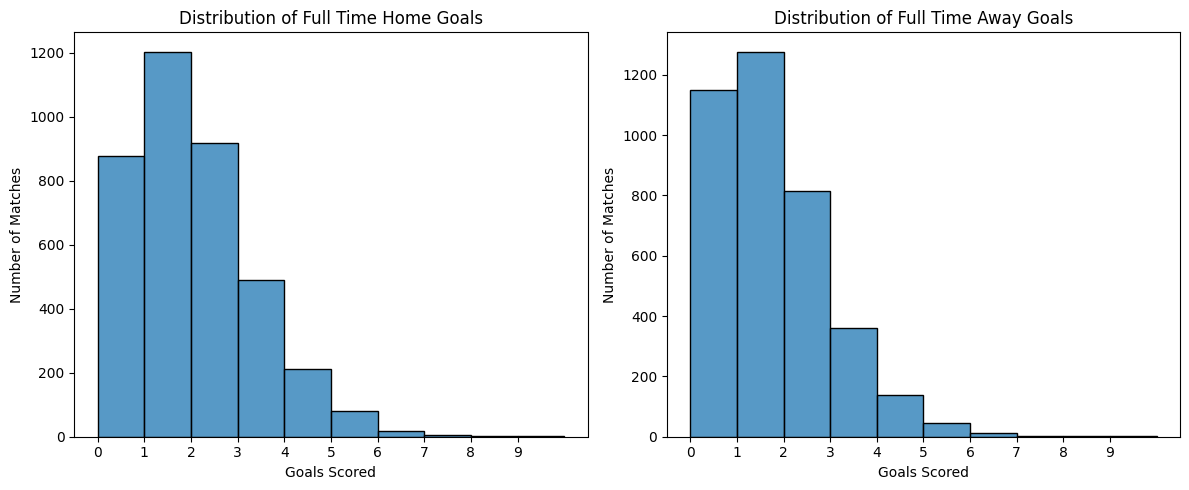

In [9]:
# Visualize the distribution of full-time home goals
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(final_df['full_time_home_goals'], bins=range(0, final_df['full_time_home_goals'].max() + 2), kde=False, stat='count')
plt.title('Distribution of Full Time Home Goals')
plt.xlabel('Goals Scored')
plt.ylabel('Number of Matches')
plt.xticks(range(0, final_df['full_time_home_goals'].max() + 1))

# Visualize the distribution of full-time away goals
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(final_df['full_time_away_goals'], bins=range(0, final_df['full_time_away_goals'].max() + 2), kde=False, stat='count')
plt.title('Distribution of Full Time Away Goals')
plt.xlabel('Goals Scored')
plt.ylabel('Number of Matches')
plt.xticks(range(0, final_df['full_time_away_goals'].max() + 1))

plt.tight_layout()
plt.show()

#### 3. Home vs Away win rates by team

### 3. Home vs. Away Win Rates by Team

In [10]:
# Calculate home win rates
home_wins = final_df[final_df['full_time_result'] == 'H']['home_team'].value_counts()
home_matches = final_df['home_team'].value_counts()
home_win_rate = (home_wins / home_matches * 100).fillna(0).sort_values(ascending=False)

# Calculate away win rates
away_wins = final_df[final_df['full_time_result'] == 'A']['away_team'].value_counts()
away_matches = final_df['away_team'].value_counts()
away_win_rate = (away_wins / away_matches * 100).fillna(0).sort_values(ascending=False)

print("Top 10 Teams by Home Win Rate:")
display(home_win_rate.head(10))

print("\nTop 10 Teams by Away Win Rate:")
display(away_win_rate.head(10))

Top 10 Teams by Home Win Rate:


,count
home_team,
Man City,76.842105
Liverpool,71.578947
Arsenal,67.894737
Tottenham,58.421053
Man United,56.315789
Chelsea,55.263158
Aston Villa,50.375940
Newcastle,47.368421
Everton,42.631579



Top 10 Teams by Away Win Rate:


,count
away_team,
Man City,64.736842
Liverpool,53.684211
Chelsea,47.368421
Arsenal,46.315789
Man United,43.157895
Tottenham,40.000000
Aston Villa,35.338346
Brentford,30.526316
Crystal Palace,30.000000


### 4. Team Points by Teams

In [11]:
# Function to assign points based on match result
def get_points(result, is_home):
    if is_home:
        if result == 'H': return 3
        if result == 'D': return 1
        if result == 'A': return 0
    else: # is_away
        if result == 'A': return 3
        if result == 'D': return 1
        if result == 'H': return 0
    return 0

# Calculate points for each match for home and away teams
final_df['home_points'] = final_df.apply(lambda row: get_points(row['full_time_result'], is_home=True), axis=1)
final_df['away_points'] = final_df.apply(lambda row: get_points(row['full_time_result'], is_home=False), axis=1)

# Aggregate total points for each team
team_points_home = final_df.groupby('home_team')['home_points'].sum()
team_points_away = final_df.groupby('away_team')['away_points'].sum()

# Combine and sum points for all teams
total_team_points = (team_points_home.add(team_points_away, fill_value=0)).sort_values(ascending=False)

print("Total Points by Team:")
display(total_team_points.head(10))

Total Points by Team:


,0
home_team,
Man City,865
Liverpool,801
Arsenal,726
Chelsea,670
Man United,662
Tottenham,631
Everton,492
Newcastle,473
West Ham,473


### 5. Red Cards Given by Referees

In [12]:
# Sum of red cards given by each referee
referee_red_cards = final_df.groupby('match_referee')[['home_team_red_cards', 'away_team_red_cards']].sum()
referee_red_cards['total_red_cards'] = referee_red_cards['home_team_red_cards'] + referee_red_cards['away_team_red_cards']

print("Referees with Most Red Cards:")
display(referee_red_cards.sort_values(by='total_red_cards', ascending=False).head(10))

Referees with Most Red Cards:


,home_team_red_cards,away_team_red_cards,total_red_cards
match_referee,,,
M Oliver,16,22,38
A Taylor,21,13,34
C Pawson,15,16,31
M Dean,9,21,30
C Kavanagh,11,11,22
S Attwell,4,18,22
P Tierney,12,9,21
J Moss,8,11,19
M Atkinson,6,12,18


### 6. Correlation Heatmap

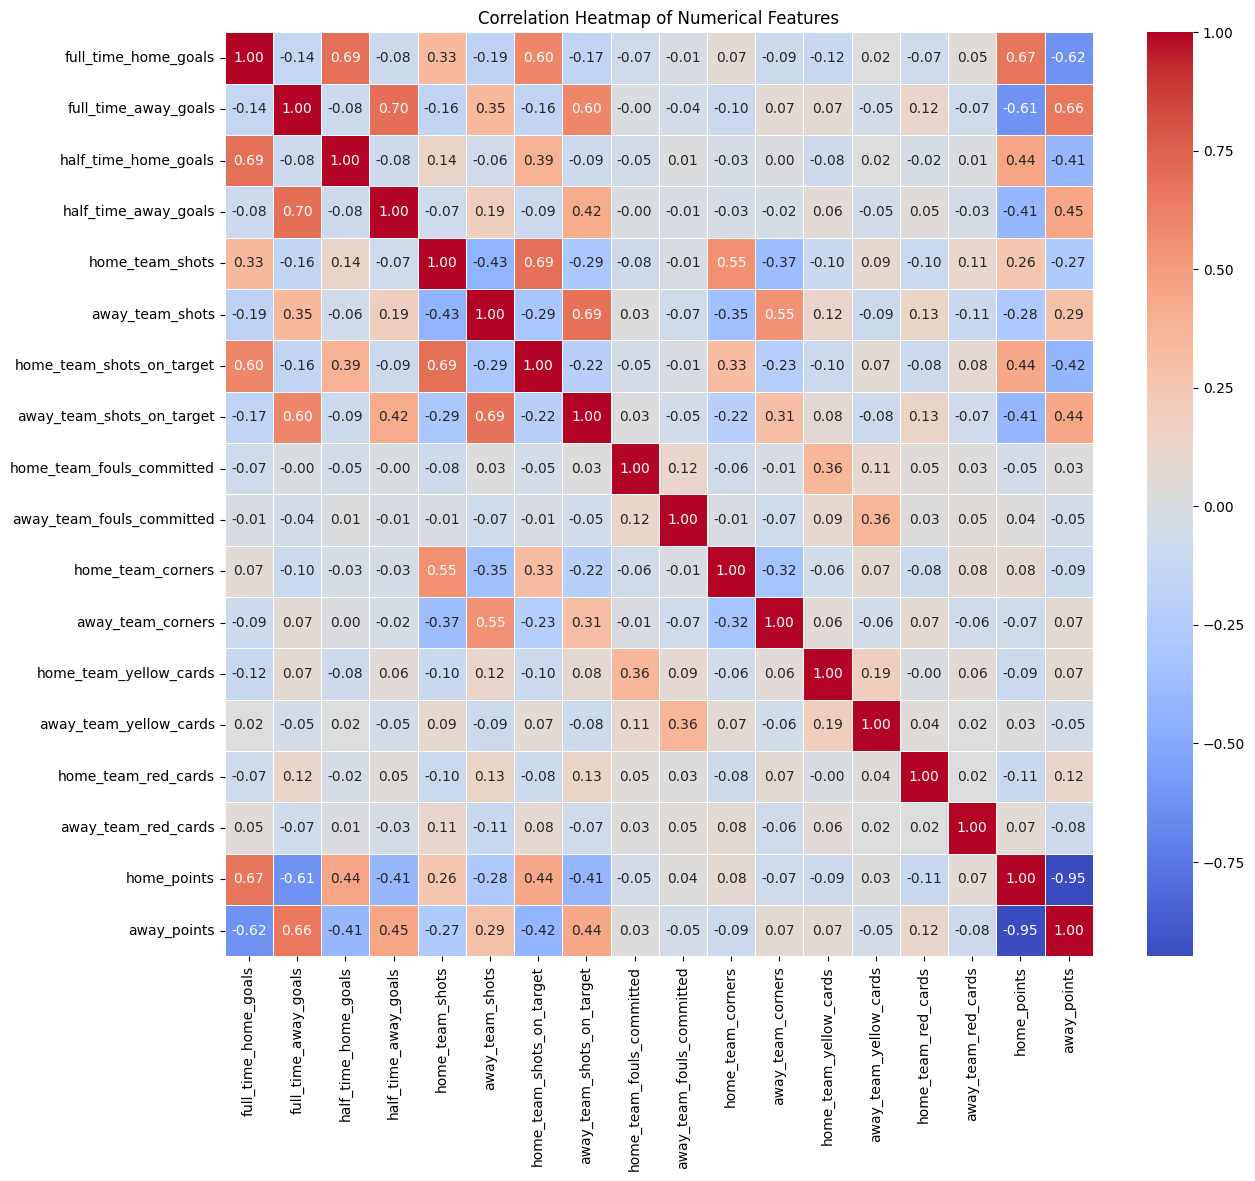

In [13]:
# Select only numerical columns for correlation analysis
numerical_df = final_df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()